In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

In [9]:
#load data set
df = pd.read_csv('data.txt', sep='\t')
df = df.drop('No.', axis=1)
print(df)

     Con_1  Con_2  Con_3  Con_4  Rejects
0    53.39  10.52   4.82      0     1.88
1    46.23  15.13   5.31      0     2.13
2    42.85  18.79   3.59      0     2.66
3    53.09  18.33   3.67      0     2.03
4    57.04  16.71   8.32      0     1.79
..     ...    ...    ...    ...      ...
295  46.99  18.05   4.36      1     1.74
296  54.42  12.79   5.66      1     2.20
297  52.43  11.33   8.95      1     2.61
298  59.31  15.73   7.17      1     2.93
299  54.74  12.78   7.72      1     2.53

[300 rows x 5 columns]


In [10]:
X = df[['Con_1', 'Con_2', 'Con_3', 'Con_4']]
t = df[['Rejects']]
print(X)
print(t)

     Con_1  Con_2  Con_3  Con_4
0    53.39  10.52   4.82      0
1    46.23  15.13   5.31      0
2    42.85  18.79   3.59      0
3    53.09  18.33   3.67      0
4    57.04  16.71   8.32      0
..     ...    ...    ...    ...
295  46.99  18.05   4.36      1
296  54.42  12.79   5.66      1
297  52.43  11.33   8.95      1
298  59.31  15.73   7.17      1
299  54.74  12.78   7.72      1

[300 rows x 4 columns]
     Rejects
0       1.88
1       2.13
2       2.66
3       2.03
4       1.79
..       ...
295     1.74
296     2.20
297     2.61
298     2.93
299     2.53

[300 rows x 1 columns]


In [11]:
# Training and Test sets 80/20 split
X_train, X_test, t_train, t_test = train_test_split(X, t, test_size=0.2)
t_train = np.ravel(t_train)
t_test = np.ravel(t_test)
#Scale inputs
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape, X_test.shape, t_train.shape, t_test.shape

((240, 4), (60, 4), (240,), (60,))

In [12]:
net = MLPRegressor(random_state=1,activation='relu', n_iter_no_change=1000, solver='adam')

In [13]:
net_hidden_layers = [(4,), (8,), (16,), (16, 8)]
net_learning_rate = [0.01, 0.001, 0.0001]
epochs = [1000, 10_000, 100_000]

for i in net_hidden_layers:
    for j in net_learning_rate:
        for k in epochs:
            net.set_params(hidden_layer_sizes = i, learning_rate_init = j, max_iter = k)
            net.fit(X_train,t_train)
            
            y_train = net.predict(X_train)
            y_test = net.predict(X_test)
            sumSqError_train = np.sum((t_train - y_train)**2)
            sumSqError_test = np.sum((t_test - y_test)**2)
            mse_train = mean_squared_error(t_train, y_train)
            mse_test = mean_squared_error(t_test, y_test)
            rmse_train = np.sqrt(mse_train)
            rmse_test = np.sqrt(mse_test)
            
            print('-----------------------------------')
            print('Hidden Layer Architecture: ', i)
            print('Learning Rate: ', j)
            print('Number of Epochs: ', k)
            print(f'Sum of sq. error - train: {sumSqError_train:.3f}')
            print(f'Sum of sq. error - test: {sumSqError_test: .3f}')
            print(f'RMSE train: {rmse_train: .3f}')
            print(f'RMSE test: {rmse_test: .3f}')
            print('-----------------------------------')

C:\Users\Diana\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


-----------------------------------
Hidden Layer Architecture:  (4,)
Learning Rate:  0.01
Number of Epochs:  1000
Sum of sq. error - train: 1.406
Sum of sq. error - test:  0.426
RMSE train:  0.077
RMSE test:  0.084
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (4,)
Learning Rate:  0.01
Number of Epochs:  10000
Sum of sq. error - train: 1.322
Sum of sq. error - test:  0.401
RMSE train:  0.074
RMSE test:  0.082
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (4,)
Learning Rate:  0.01
Number of Epochs:  100000
Sum of sq. error - train: 1.322
Sum of sq. error - test:  0.401
RMSE train:  0.074
RMSE test:  0.082
-----------------------------------


C:\Users\Diana\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


-----------------------------------
Hidden Layer Architecture:  (4,)
Learning Rate:  0.001
Number of Epochs:  1000
Sum of sq. error - train: 2.567
Sum of sq. error - test:  0.912
RMSE train:  0.103
RMSE test:  0.123
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (4,)
Learning Rate:  0.001
Number of Epochs:  10000
Sum of sq. error - train: 2.342
Sum of sq. error - test:  0.848
RMSE train:  0.099
RMSE test:  0.119
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (4,)
Learning Rate:  0.001
Number of Epochs:  100000
Sum of sq. error - train: 2.342
Sum of sq. error - test:  0.848
RMSE train:  0.099
RMSE test:  0.119
-----------------------------------


C:\Users\Diana\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


...

-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.01
Number of Epochs:  1000
Sum of sq. error - train: 0.194
Sum of sq. error - test:  0.181
RMSE train:  0.028
RMSE test:  0.055
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.01
Number of Epochs:  10000
Sum of sq. error - train: 0.185
Sum of sq. error - test:  0.169
RMSE train:  0.028
RMSE test:  0.053
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.01
Number of Epochs:  100000
Sum of sq. error - train: 0.185
Sum of sq. error - test:  0.169
RMSE train:  0.028
RMSE test:  0.053
-----------------------------------


C:\Users\Diana\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.001
Number of Epochs:  1000
Sum of sq. error - train: 1.975
Sum of sq. error - test:  0.547
RMSE train:  0.091
RMSE test:  0.095
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.001
Number of Epochs:  10000
Sum of sq. error - train: 1.437
Sum of sq. error - test:  0.500
RMSE train:  0.077
RMSE test:  0.091
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.001
Number of Epochs:  100000
Sum of sq. error - train: 1.437
Sum of sq. error - test:  0.500
RMSE train:  0.077
RMSE test:  0.091
-----------------------------------


C:\Users\Diana\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.0001
Number of Epochs:  1000
Sum of sq. error - train: 204.847
Sum of sq. error - test:  28.505
RMSE train:  0.924
RMSE test:  0.689
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.0001
Number of Epochs:  10000
Sum of sq. error - train: 5.650
Sum of sq. error - test:  1.391
RMSE train:  0.153
RMSE test:  0.152
-----------------------------------
-----------------------------------
Hidden Layer Architecture:  (16, 8)
Learning Rate:  0.0001
Number of Epochs:  100000
Sum of sq. error - train: 5.650
Sum of sq. error - test:  1.391
RMSE train:  0.153
RMSE test:  0.152
-----------------------------------


Sum of sq. error - train: 0.212
Sum of sq. error - test:  0.092
RMSE train:  0.030
RMSE test:  0.039


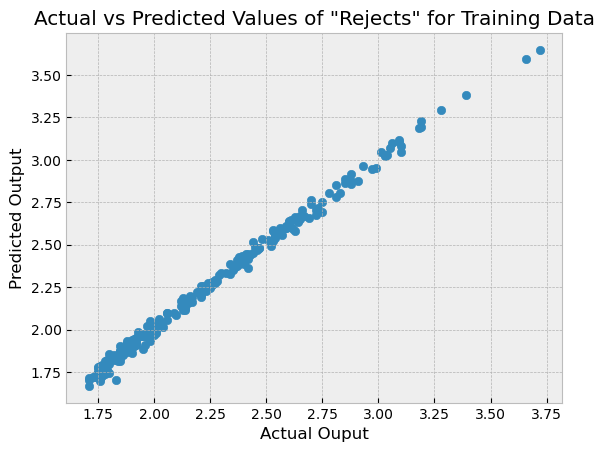

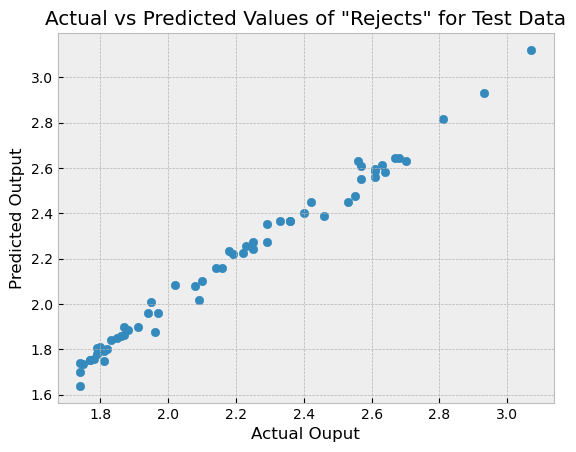

In [20]:
#final model with best params
net_final = MLPRegressor(random_state=1,activation='relu', n_iter_no_change=1000, solver='adam',
                        hidden_layer_sizes = (16,), learning_rate_init = 0.01, max_iter = 10000)

#fit model to training data
net_final.fit(X_train, t_train)
# make predictions on training and testing sets
y_train = net_final.predict(X_train)
y_test = net_final.predict(X_test)

# calculate metrics
sumSqError_train = np.sum((t_train - y_train)**2)
sumSqError_test = np.sum((t_test - y_test)**2)


mse_train = mean_squared_error(t_train, y_train)
mse_test = mean_squared_error(t_test, y_test)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)


print(f'Sum of sq. error - train: {sumSqError_train:.3f}')
print(f'Sum of sq. error - test: {sumSqError_test: .3f}')
print(f'RMSE train: {rmse_train: .3f}')
print(f'RMSE test: {rmse_test: .3f}')

#plot the actual and predicted values of the output "rejects" for the training and test data sets

#Training Data plot
plt.figure()
plt.scatter(t_train, y_train,label='Training Data')
plt.title('Actual vs Predicted Values of "Rejects" for Training Data')
plt.xlabel('Actual Ouput')
plt.ylabel('Predicted Output')
#plt.legend()
plt.show()

#Test Data plot
plt.figure()
plt.scatter(t_test, y_test, label='Test Data')
plt.title('Actual vs Predicted Values of "Rejects" for Test Data')
plt.xlabel('Actual Ouput')
plt.ylabel('Predicted Output')
#plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(t_train, y_train, color='royalblue', label='Training Data')
plt.scatter(t_test, y_test, color='tomato', label='Test Data')
plt.plot([t.min(), t.max()], [t.min(), t.max()], 'k--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Rejects')
plt.ylabel('Predicted Rejects')
plt.title('Actual vs Predicted Values of Rejects')
plt.legend()
plt.show()

In [76]:
net = MLPRegressor(hidden_layer_sizes=(16,8), random_state=1, 
                   max_iter=500, tol=0.1, activation='relu')
net.fit(X_train, t_train)
y_pred = net.predict(X_test)
accuracy_score(t_test, y_pred)

ValueError: continuous is not supported

In [ ]:
 print(f'Sum of sq. error - train: {sumSqError_train:.4f}')
            print(f'Sum of sq. error - test: {sumSqError_test: .4f}')
            print(f'RMSE train: {rmse_train: .4f}')
            print(f'RMSE test: {rmse_test: .4f}')

In [45]:
y_pred_train = net.predict(X_train)
y_pred_test  = net.predict(X_test)
sse_train = ((t_train - y_pred_train)**2).sum()
sse_test  = ((t_test - y_pred_test)**2).sum()

SSE train: 1096.2131353735047 SSE test: 293.38384539691833


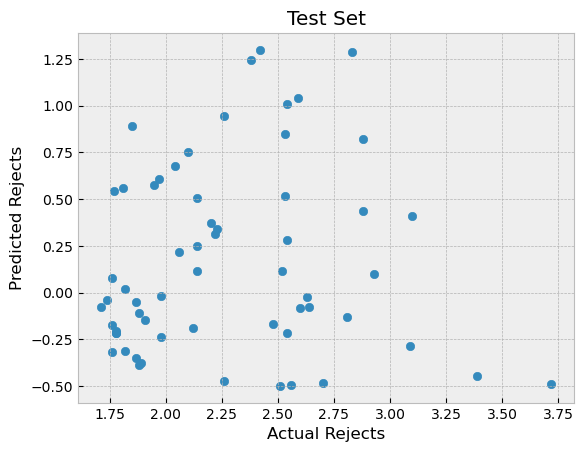

In [46]:

print("SSE train:", sse_train, "SSE test:", sse_test)
plt.scatter(t_test, y_pred_test)
plt.xlabel("Actual Rejects"); plt.ylabel("Predicted Rejects"); plt.title("Test Set")
plt.show()